This document shows how to use the models to process Sentinel-2 images. The steps presented here are mostly the same than in [scripts/predict_tile.py](https://github.com/mayrajeo/ship-detection/blob/main/scripts/predict_tile.py).

## Acquire the data

As usual, data can be accessed from [Copernicus Data Space Ecosystem (CDSE)](https://documentation.dataspace.copernicus.eu/Registration.html). The following products were used as the test data.

|Location|Product name|Number of annotations|
|--------|------------|---------------------|
|Bothnian sea|S2B_MSIL1C_20210714T100029_N0301_R122_T34VEN_20210714T121056|450|
|Bothnian sea|S2B_MSIL1C_20220619T100029_N0400_R122_T34VEN_20220619T104419|66|
|Bothnian sea|S2A_MSIL1C_20220624T100041_N0400_R122_T34VEN_20220624T120211|424|
|Bothnian sea|S2A_MSIL1C_20220813T095601_N0400_R122_T34VEN_20220813T120233|399|
|Kvarken|S2B_MSIL1C_20210714T100029_N0301_R122_T34VEN_20210714T121056|83|
|Kvarken|S2B_MSIL1C_20220712T100559_N0400_R022_T34VER_20220712T121613|184|
|Kvarken|S2A_MSIL1C_20220826T100611_N0400_R022_T34VER_20220826T135136|88|

We use `S2A_MSIL1C_20220624T100041_N0400_R122_T34VEN_20220624T120211` as the data for this example. First download the L1C-TCI mosaic with

```bash
python scripts/cdse_odata_tci.py S2A_MSIL1C_20220624T100041_N0400_R122_T34VEN_20220624T120211.safe --creds_file <path_to_creds_file> --target_path <where_to_download>
```

In case the TCI isn't found, download the full product and convert the data to TCI, as seen in [Dataset conversion](dataset_conversion.qmd).

## Run the model

First import the required packages. [sahi](https://github.com/obss/sahi) is used for tiled inference.

In [ ]:
import sys, os
from pathlib import Path
import torch
import geopandas as gpd
import pandas as pd
import shapely
import matplotlib.pyplot as plt
from sahi.models.ultralytics import UltralyticsDetectionModel
import rasterio as rio
import rasterio.plot as rioplot
from sahi.predict import get_sliced_prediction
sys.path.insert(1, '..')

from src.sahi_utils import *

Set the model path, data path, device and other parameters:

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
half = True
model_path = '../revision_models/yolo11s_Adam/tci_pt/weights/best.pt' # Location for the checkpoint to use
conf_th = 0.286 # confidence threshold with highest validation F1-score

Then initialize `UltralyticsDetectionModel` and overrides for the model.

In [ ]:
det_model = UltralyticsDetectionModel(model_path=model_path,
                                      device=device,
                                      confidence_threshold=conf_th,
                                      image_size=640)

det_model.model.overrides.update({'half': half})

Now `get_sliced_prediction` can be used to perform tiled inference for the tile:

In [ ]:
tile = '../tcil1c_test/34VEN/20220624.tif'

sliced_pred_results = get_sliced_prediction(tile, det_model, slice_width=320, slice_height=320,
                                            overlap_height_ratio=0.2, overlap_width_ratio=0.2, perform_standard_pred=False,
                                            verbose=2)

Performing prediction on 1677 slices.
Slicing performed in 2.2600011825561523 seconds.
Prediction performed in 51.64028072357178 seconds.


`sliced_pred_results` contains `object_prediction_list`, which can then be georeferenced with `georef_sahi_preds`:

In [ ]:
georef_preds = georef_sahi_preds(preds=sliced_pred_results.object_prediction_list, path_to_ref_img=tile)
georef_preds['type'] = 'boat'
georef_preds.head()

,label,geometry,score,type
0,0,"POLYGON ((545705 6706471.25, 545705 6706428.75...",0.737305,boat
1,0,"POLYGON ((515035 6774110, 515035 6773943.75, 5...",0.725098,boat
2,0,"POLYGON ((524502.5 6779197.5, 524502.5 6779155...",0.705566,boat
3,0,"POLYGON ((518555 6740170.625, 518555 6740105.6...",0.697754,boat
4,0,"POLYGON ((515991.875 6735191.875, 515991.875 6...",0.692871,boat


Plot the data:

<Axes: >

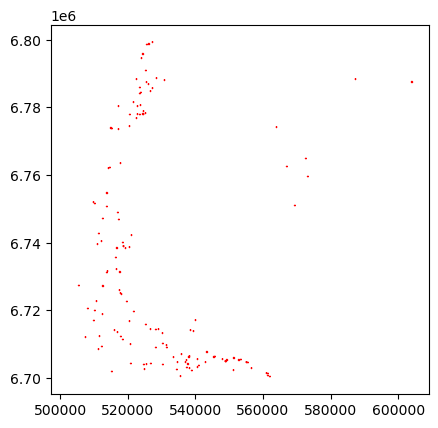

In [ ]:
georef_preds.plot(facecolor='none', edgecolor='red')

## Cleaning stationary targets and other obvious false positives from the data

In [ ]:
from src.data_paths import *

At this step, the data contains all the targets the model considered to be a marine vessel. However, there are some amount of stationary non-vessel targets that look exactly like boats, as well as possibly some targets that are not on water. These are fairly straightforward to filter from the data using external datasets. Most of the cleaning is done based on [Topographic Database](https://www.maanmittauslaitos.fi/en/maps-and-spatial-data/datasets-and-interfaces/product-descriptions/topographic-database) by the National Land Survey of Finland, while the beacons and other similar targets can be cleaned using the data fron the Finnish Transport Infrastructure Agency.

### Predictions not on water

This step filters the detections whose centroid points are on land. The layers `jarvi` (lakes), `meri` (sea) and `virtavesialue` (rivers etc) are used here.

In order to speed up the processing, these data are already extracted from the topographic database.

In [ ]:
waters = gpd.read_file(f'{PATH_TO_MTK_DATA}/34VEN_waters.gpkg', layer='waters').to_crs(georef_preds.crs)

Filtering is done by 

1) changing the geometries of the predictions to their centroid points
2) keep only the geometries which are located on water

In [ ]:
georef_preds['centroids'] = georef_preds.centroid
georef_preds.set_geometry('centroids', inplace=True)
joined = georef_preds.sjoin(waters, how='inner', predicate='within')[['label', 'score', 'geometry', 'centroids', 'type']]
georef_preds.loc[~georef_preds.index.isin(joined.index), 'type'] = 'land'

### Predictions on above water rock areas

There are two types of above water rock reference geometries: area (layer `vesikivikko`) and points (few target classes in layer `vesikivi`). Both are filtered from the data, but the point data is filtered at a later step.

`vesikivikko` works same way than filtering based on water:

In [ ]:
tot_bounds_3067 = tuple(georef_preds.to_crs('EPSG:3067').total_bounds) # Bounds in EPSG:3067 for faster reading
rocks = gpd.read_file(PATH_TO_OTHER, layer='vesikivikko', bbox=tot_bounds_3067).dissolve(by='kohdeluokka')
rocks = rocks.to_crs(georef_preds.crs)

joined = gpd.sjoin(georef_preds, rocks, predicate='within', how='inner')[['label', 'score', 'geometry', 'centroids', 'type']]
georef_preds.loc[georef_preds.index.isin(joined.index), 'type'] = 'area_rocks'

### Fisheries

There is no available data for the locations of fisheries, so those data are manually derived from aerial images and satellite data.

In [ ]:
fisheries = gpd.read_file(PATH_TO_FISHERIES, bbox=tot_bounds_3067)
fisheries = rocks.to_crs(georef_preds.crs)

joined = gpd.sjoin(georef_preds, fisheries, predicate='within', how='inner')[['label', 'score', 'geometry', 'centroids', 'type']]
georef_preds.loc[georef_preds.index.isin(joined.index), 'type'] = 'fisheries'

### Individual large rocks

Now the geometry can be reverted to bounding boxes.

In [ ]:
georef_preds = georef_preds.set_geometry('geometry')[['label', 'score', 'geometry', 'type']]

Next we drop the detections that contain rocks above waterline within them

In [ ]:
above_water_rocks = gpd.read_file(PATH_TO_OTHER, layer='vesikivi', bbox=tot_bounds_3067).to_crs(georef_preds.crs)
above_water_rocks = above_water_rocks[above_water_rocks.kohdeluokka.isin([38511,38512,38513])]
georef_preds.loc[(any(g.contains(above_water_rocks.geometry)) for g in georef_preds.geometry), 'type'] = 'rock'

### Beacons etc

Sector lights, lighthouses and such beacons are visible from satellite images, and are confused with small vessels. The data is available from The Finnish Transport Infrastructure Agency.

In [ ]:
beacons = gpd.read_file(PATH_TO_BEACONS, tot_bounds_3067).to_crs(georef_preds.crs)
beacons = beacons[beacons.ty_jnr.isin([1,2,3,4,5,8])]
georef_preds.loc[(any(g.contains(beacons.geometry)) for g in georef_preds.geometry), 'type'] = 'beacon'

/home/mayrajeo/miniconda3/envs/ml-env/lib/python3.11/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Point' is converted to 'Point Z'
  return ogr_read(


### Filtering based on size

Final sanity check is to drop the predictions that are obviously too large. Here we use 750 meters as the threshold for the longer side of the bounding box. These kind of errors are extremely rare.

In [ ]:
def get_longer_edge(geom:shapely.geometry.Polygon) -> float:
    x, y = shapely.geometry.box(*geom.bounds).exterior.coords.xy
    edge_lengths = (shapely.geometry.Point(x[0],y[0]).distance(shapely.geometry.Point(x[1],y[1])),
                    shapely.geometry.Point(x[1],y[1]).distance(shapely.geometry.Point(x[2],y[2])))
    return max(edge_lengths)

In [ ]:
georef_preds['max_edge'] = georef_preds.geometry.apply(get_longer_edge)
georef_preds.loc[georef_preds.max_edge >= 750, 'type'] = 'size'

## Plot the cleaned data

Finally plot how many false positives were cleaned from the predictions: 

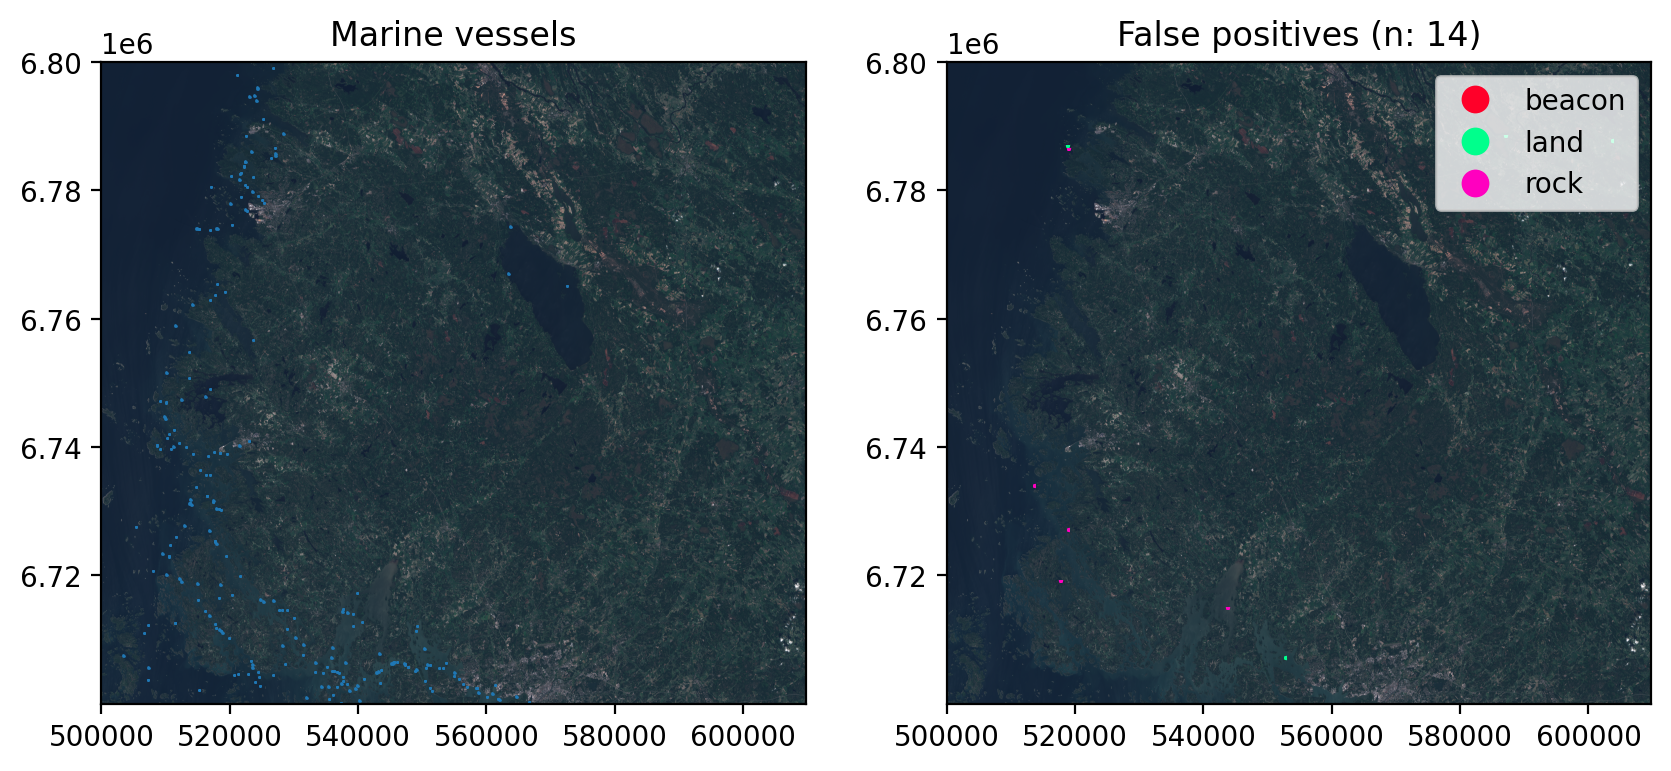

In [ ]:
fig, axs = plt.subplots(1,2, dpi=200, figsize=(10,6))

with rio.open(tile) as src:
    rioplot.show(src, ax=axs[0])
    rioplot.show(src, ax=axs[1])
    
georef_preds[georef_preds['type'] == 'boat'].plot(ax=axs[0], column='type', facecolor='none')
georef_preds[georef_preds['type'] != 'boat'].plot(ax=axs[1], column='type', linewidth=1.5, facecolor='none', legend=True, cmap='gist_rainbow')
axs[0].set_title('Marine vessels')
axs[1].set_title(f"False positives (n: {len(georef_preds[georef_preds['type'] != 'boat'])})")
plt.show()